# Лабораторная работа №2 по дисциплине "Основы нейронных сетей"

Выполнили cтуденты группы 3311:
- Шарпинский Денис
- Локтионов Тимофей
- Суздалева Алёна

Датасет: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather?resource=download

Используемый датасет содержит почасовые данные энергосистемы Испании и погодные наблюдения по крупным городам Испании за тот же временной период. Энергетические данные описывают фактическую и прогнозную нагрузку, генерацию электроэнергии по источникам и цены. Погодные данные используются как дополнительные внешние факторы, потенциально влияющие на уровень энергопотребления. Для объединения таблиц погодные признаки агрегируются по времени, после чего соединяются с энергетическими данными по временной метке.

Можно сформулировать задачу:

По предыдущим 24 часам энергетических и погодных признаков предсказать класс нагрузки энергосистемы Испании на следующий час.

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical

In [10]:
energy_df = pd.read_csv("energy_dataset.csv")
weather_df = pd.read_csv("weather_features.csv")

In [14]:
print("ENERGY DATASET")
print("=" * 80)

display(energy_df.head())

print("\nShape:")
print(energy_df.shape)

print("\nColumns:")
print(energy_df.columns.tolist())

print("\nInfo:")
energy_df.info()

print("\nMissing values:")
display(energy_df.isna().sum().sort_values(ascending=False).head(20))

print("\nDescribe:")
display(energy_df.describe())

ENERGY DATASET


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04



Shape:
(35064, 29)

Columns:
['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind offshore eday ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       N

generation hydro pumped storage aggregated     35064
forecast wind offshore eday ahead              35064
total load actual                                 36
generation hydro run-of-river and poundage        19
generation hydro pumped storage consumption       19
generation waste                                  19
generation marine                                 19
generation fossil oil                             19
generation biomass                                19
generation fossil peat                            18
generation fossil gas                             18
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation wind onshore                           18
generation geothermal                             18
generation fossil oil shale                       18
generation fossil hard coal                       18
generation solar                                  18
generation other renewable                    


Describe:


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.000000,35046.000000,35046.0,35046.000000,35046.000000,35045.000000,35046.0,35046.0,35046.0,0.0,...,35045.000000,35046.0,35046.000000,35064.000000,0.0,35064.000000,35064.000000,35028.000000,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,NaN,...,269.452133,0.0,5464.479769,1439.066735,NaN,5471.216689,28712.129962,28696.939905,49.874341,57.884023
std,85.353943,354.568590,0.0,2201.830478,1961.601013,52.520673,0.0,0.0,0.0,NaN,...,50.195536,0.0,3213.691587,1677.703355,NaN,3176.312853,4594.100854,4574.987950,14.618900,14.204083
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,...,0.000000,0.0,0.000000,0.000000,NaN,237.000000,18105.000000,18041.000000,2.060000,9.330000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,...,240.000000,0.0,2933.000000,69.000000,NaN,2979.000000,24793.750000,24807.750000,41.490000,49.347500
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,...,279.000000,0.0,4849.000000,576.000000,NaN,4855.000000,28906.000000,28901.000000,50.520000,58.020000
75%,433.000000,757.000000,0.0,6429.000000,5838.750000,330.000000,0.0,0.0,0.0,NaN,...,310.000000,0.0,7398.000000,2636.000000,NaN,7353.000000,32263.250000,32192.000000,60.530000,68.010000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,...,357.000000,0.0,17436.000000,5836.000000,NaN,17430.000000,41390.000000,41015.000000,101.990000,116.800000


In [12]:
print("WEATHER FEATURES")
print("=" * 80)

display(weather_df.head())

print("\nShape:")
print(weather_df.shape)

print("\nColumns:")
print(weather_df.columns.tolist())

print("\nInfo:")
weather_df.info()

print("\nMissing values:")
display(weather_df.isna().sum().sort_values(ascending=False).head(20))

print("\nDescribe:")
display(weather_df.describe())

WEATHER FEATURES


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n



Shape:
(178396, 17)

Columns:
['dt_iso', 'city_name', 'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'weather_id', 'weather_main', 'weather_description', 'weather_icon']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  str    
 1   city_name            178396 non-null  str    
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              17

dt_iso                 0
city_name              0
temp                   0
temp_min               0
temp_max               0
pressure               0
humidity               0
wind_speed             0
wind_deg               0
rain_1h                0
rain_3h                0
snow_3h                0
clouds_all             0
weather_id             0
weather_main           0
weather_description    0
weather_icon           0
dtype: int64


Describe:


,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.000000,178396.000000,178396.000000,1.783960e+05,178396.000000,178396.00000,178396.000000,178396.000000,178396.000000,178396.000000,178396.000000,178396.000000
mean,289.618605,288.330442,291.091267,1.069261e+03,68.423457,2.47056,166.591190,0.075492,0.000380,0.004763,25.073292,759.831902
std,8.026199,7.955491,8.612454,5.969632e+03,21.902888,2.09591,116.611927,0.398847,0.007288,0.222604,30.774129,108.733223
min,262.240000,262.240000,262.240000,0.000000e+00,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000
25%,283.670000,282.483602,284.650000,1.013000e+03,53.000000,1.00000,55.000000,0.000000,0.000000,0.000000,0.000000,800.000000
50%,289.150000,288.150000,290.150000,1.018000e+03,72.000000,2.00000,177.000000,0.000000,0.000000,0.000000,20.000000,800.000000
75%,295.150000,293.730125,297.150000,1.022000e+03,87.000000,4.00000,270.000000,0.000000,0.000000,0.000000,40.000000,801.000000
max,315.600000,315.150000,321.150000,1.008371e+06,100.000000,133.00000,360.000000,12.000000,2.315000,21.500000,100.000000,804.000000


In [13]:
print("Energy time column example:")
display(energy_df[["time"]].head())

print("Weather time column example:")
display(weather_df[["dt_iso", "city_name"]].head())

Energy time column example:


,time
0,2015-01-01 00:00:00+01:00
1,2015-01-01 01:00:00+01:00
2,2015-01-01 02:00:00+01:00
3,2015-01-01 03:00:00+01:00
4,2015-01-01 04:00:00+01:00


Weather time column example:


,dt_iso,city_name
0,2015-01-01 00:00:00+01:00,Valencia
1,2015-01-01 01:00:00+01:00,Valencia
2,2015-01-01 02:00:00+01:00,Valencia
3,2015-01-01 03:00:00+01:00,Valencia
4,2015-01-01 04:00:00+01:00,Valencia


После первичного анализа данных видно, что файл `energy_dataset.csv` содержит основной почасовой временной ряд энергосистемы: фактическую нагрузку, прогноз нагрузки, генерацию по различным источникам и цены на электроэнергию. Размер датасета составляет 35064 строки и 29 столбцов, что соответствует примерно четырём годам почасовых наблюдений. В данных есть несколько полностью пустых столбцов, а также небольшое количество пропусков в отдельных энергетических признаках, поэтому потребуется очистка: удалить полностью пустые и неинформативные столбцы, а пропущенные значения заполнить или интерполировать.

Файл `weather_features.csv` содержит погодные признаки: температуру, давление, влажность, скорость ветра, осадки, облачность и другие параметры. Его размер больше, чем у энергетического датасета, потому что погодные данные представлены отдельно для нескольких городов. Поэтому напрямую объединять два файла нельзя: сначала нужно привести время к единому формату, затем агрегировать погодные данные по времени, например усреднить числовые погодные признаки по всем городам, и только после этого объединить их с энергетическими данными.

Дальнейший план работы: привести временные колонки к типу `datetime`, отсортировать данные по времени, проверить дубликаты, определить полностью пустые и константные столбцы, обработать пропуски, агрегировать погодные данные и объединить оба датасета в один многофакторный временной ряд. После этого можно будет сформировать целевую переменную, создать временные окна для RNN, нормализовать признаки и перейти к построению моделей Simple RNN, LSTM и GRU.

In [15]:
# Копируем исходные датафреймы, чтобы не портить оригиналы
energy = energy_df.copy()
weather = weather_df.copy()

# Приводим временные колонки к datetime.
# utc=True нужен, чтобы корректно обработать часовые пояса +01:00 / +02:00.
energy["time"] = pd.to_datetime(energy["time"], utc=True)
weather["dt_iso"] = pd.to_datetime(weather["dt_iso"], utc=True)

# Сортируем по времени
energy = energy.sort_values("time").reset_index(drop=True)
weather = weather.sort_values("dt_iso").reset_index(drop=True)

print("ENERGY TIME RANGE")
print(energy["time"].min(), "->", energy["time"].max())
print()

print("WEATHER TIME RANGE")
print(weather["dt_iso"].min(), "->", weather["dt_iso"].max())
print()

print("ENERGY DUPLICATES BY TIME:")
print(energy["time"].duplicated().sum())
print()

print("WEATHER DUPLICATES BY TIME + CITY:")
print(weather.duplicated(subset=["dt_iso", "city_name"]).sum())
print()

print("WEATHER CITIES:")
print(weather["city_name"].value_counts())
print()

print("ENERGY FULLY EMPTY COLUMNS:")
empty_energy_cols = energy.columns[energy.isna().all()].tolist()
print(empty_energy_cols)
print()

print("ENERGY CONSTANT COLUMNS:")
constant_energy_cols = []
for col in energy.columns:
    if col == "time":
        continue
    if energy[col].nunique(dropna=True) <= 1:
        constant_energy_cols.append(col)

print(constant_energy_cols)
print()

print("ENERGY MISSING VALUES > 0:")
display(
    energy.isna()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda s: s > 0]
)
print()

print("WEATHER NUMERIC EXTREMES:")
weather_numeric_cols = weather.select_dtypes(include=["number"]).columns.tolist()
display(weather[weather_numeric_cols].describe().T[["min", "max", "mean", "std"]])

ENERGY TIME RANGE
2014-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00

WEATHER TIME RANGE
2014-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00

ENERGY DUPLICATES BY TIME:
0

WEATHER DUPLICATES BY TIME + CITY:
3076

WEATHER CITIES:
city_name
Madrid        36267
Bilbao        35951
Seville       35557
 Barcelona    35476
Valencia      35145
Name: count, dtype: int64

ENERGY FULLY EMPTY COLUMNS:
['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']

ENERGY CONSTANT COLUMNS:
['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation marine', 'generation wind offshore', 'forecast wind offshore eday ahead']

ENERGY MISSING VALUES > 0:


generation hydro pumped storage aggregated     35064
forecast wind offshore eday ahead              35064
total load actual                                 36
generation hydro run-of-river and poundage        19
generation hydro pumped storage consumption       19
generation waste                                  19
generation marine                                 19
generation fossil oil                             19
generation biomass                                19
generation fossil peat                            18
generation fossil gas                             18
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation wind onshore                           18
generation geothermal                             18
generation fossil oil shale                       18
generation fossil hard coal                       18
generation solar                                  18
generation other renewable                    


WEATHER NUMERIC EXTREMES:


,min,max,mean,std
temp,262.24,315.600,289.618605,8.026199
temp_min,262.24,315.150,288.330442,7.955491
temp_max,262.24,321.150,291.091267,8.612454
pressure,0.00,1008371.000,1069.260740,5969.631893
humidity,0.00,100.000,68.423457,21.902888
wind_speed,0.00,133.000,2.470560,2.095910
wind_deg,0.00,360.000,166.591190,116.611927
rain_1h,0.00,12.000,0.075492,0.398847
rain_3h,0.00,2.315,0.000380,0.007288
snow_3h,0.00,21.500,0.004763,0.222604


Временные диапазоны двух таблиц полностью совпадают: обе начинаются 2014-12-31 23:00:00 UTC и заканчиваются 2018-12-31 22:00:00 UTC. Это значит, что энергетические и погодные данные действительно относятся к одному периоду и могут быть объединены по времени.

В `energy_dataset.csv` одна строка соответствует одному часу, дубликатов по времени нет. Это хороший основной временной ряд. В нём есть два полностью пустых столбца и несколько константных столбцов, которые не несут информации для модели. Их нужно удалить. Остальные пропуски небольшие — около 17–36 значений на 35064 строки, поэтому их лучше не удалять, а заполнить интерполяцией по времени.

В `weather_features.csv` данные представлены по нескольким городам Испании. Есть 3076 дубликатов по паре `dt_iso + city_name`, а также у города ` Barcelona` заметен пробел в начале названия. Поэтому сначала нужно очистить названия городов, затем агрегировать дубликаты и только после этого усреднить погодные признаки по городам для каждого часа.

В погодных данных также видны выбросы: например, давление `1008371` и давление `0`, что физически некорректно для атмосферного давления. Такие значения нужно заменить на пропуски и затем заполнить корректными значениями. После этого погодные признаки можно объединить с энергетическими данными по временной колонке.

Дальше выполняем этап предобработки: удаляем пустые и константные энергетические признаки, заполняем пропуски, чистим погодные выбросы, агрегируем погоду по времени и объединяем две таблицы в один многофакторный временной ряд.

In [16]:
# Создаем рабочие копии
energy_clean = energy.copy()
weather_clean = weather.copy()

# Убираем лишние пробелы в названиях городов
weather_clean["city_name"] = weather_clean["city_name"].str.strip()

# Удаляем полностью пустые и константные столбцы из energy
cols_to_drop = list(set(empty_energy_cols + constant_energy_cols))

energy_clean = energy_clean.drop(columns=cols_to_drop)

print("Удалены столбцы из energy:")
print(cols_to_drop)
print()

print("Energy shape after drop:")
print(energy_clean.shape)

Удалены столбцы из energy:
['generation wind offshore', 'forecast wind offshore eday ahead', 'generation fossil coal-derived gas', 'generation hydro pumped storage aggregated', 'generation fossil oil shale', 'generation fossil peat', 'generation marine', 'generation geothermal']

Energy shape after drop:
(35064, 21)


In [17]:
# Делаем time индексом, чтобы корректно интерполировать временной ряд
energy_clean = energy_clean.set_index("time")

# Интерполяция числовых пропусков по времени
energy_clean = energy_clean.interpolate(method="time")

# Если в начале/конце остались пропуски, заполняем соседними значениями
energy_clean = energy_clean.ffill().bfill()

# Возвращаем time обратно в колонку
energy_clean = energy_clean.reset_index()

print("Missing values in energy after cleaning:")
display(
    energy_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda s: s > 0]
)

display(energy_clean.head())

Missing values in energy after cleaning:


Series([], dtype: int64)

,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,...,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,...,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,...,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,...,75.0,50.0,191.0,5238.0,2.0,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,...,74.0,42.0,189.0,4935.0,9.0,4861.0,21785.0,20264.0,38.41,56.04


In [18]:
# Оставляем только числовые погодные признаки, которые имеют физический смысл
weather_feature_cols = [
    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "wind_deg",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

# Заменяем явно некорректное давление на NaN
# Нормальное атмосферное давление обычно находится примерно в диапазоне 900-1100 hPa
weather_clean.loc[
    (weather_clean["pressure"] < 900) | (weather_clean["pressure"] > 1100),
    "pressure"
] = np.nan

# Заменяем явно некорректную влажность
weather_clean.loc[
    (weather_clean["humidity"] < 0) | (weather_clean["humidity"] > 100),
    "humidity"
] = np.nan

# Заменяем явно подозрительную скорость ветра
# 133 — физически выглядит как выброс для обычного погодного датасета
weather_clean.loc[
    weather_clean["wind_speed"] > 60,
    "wind_speed"
] = np.nan

# Переводим температуру из Кельвинов в градусы Цельсия для читаемости
for col in ["temp", "temp_min", "temp_max"]:
    weather_clean[col] = weather_clean[col] - 273.15

display(weather_clean[weather_feature_cols].describe().T[["min", "max", "mean", "std"]])

,min,max,mean,std
temp,-10.91,42.450,16.468605,8.026199
temp_min,-10.91,42.000,15.180442,7.955491
temp_max,-10.91,48.000,17.941267,8.612454
pressure,918.00,1090.000,1016.208788,12.448766
humidity,0.00,100.000,68.423457,21.902888
wind_speed,0.00,54.000,2.469483,2.067887
wind_deg,0.00,360.000,166.591190,116.611927
rain_1h,0.00,12.000,0.075492,0.398847
rain_3h,0.00,2.315,0.000380,0.007288
snow_3h,0.00,21.500,0.004763,0.222604


In [19]:
# 1. Сначала агрегируем дубликаты по одному городу и одному часу
weather_by_city_hour = (
    weather_clean
    .groupby(["dt_iso", "city_name"], as_index=False)[weather_feature_cols]
    .mean()
)

print("Weather shape after city-hour aggregation:")
print(weather_by_city_hour.shape)

print("Duplicates by dt_iso + city_name after aggregation:")
print(weather_by_city_hour.duplicated(subset=["dt_iso", "city_name"]).sum())
print()

# 2. Затем усредняем погодные признаки по всем городам на каждый час
weather_agg = (
    weather_by_city_hour
    .groupby("dt_iso", as_index=False)[weather_feature_cols]
    .mean()
)

# Заполняем возможные пропуски после очистки выбросов
weather_agg = weather_agg.set_index("dt_iso")
weather_agg = weather_agg.interpolate(method="time").ffill().bfill()
weather_agg = weather_agg.reset_index()

# Переименовываем колонку времени для объединения
weather_agg = weather_agg.rename(columns={"dt_iso": "time"})

print("Weather aggregated shape:")
print(weather_agg.shape)

display(weather_agg.head())

Weather shape after city-hour aggregation:
(175320, 13)
Duplicates by dt_iso + city_name after aggregation:
0

Weather aggregated shape:
(35064, 12)


,time,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,-0.658537,-0.658537,-0.658537,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,-0.637300,-0.637300,-0.637300,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,-1.050862,-1.050862,-1.050862,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,-1.060531,-1.060531,-1.060531,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,-1.004100,-1.004100,-1.004100,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0


In [20]:
df = pd.merge(
    energy_clean,
    weather_agg,
    on="time",
    how="inner"
)

print("Merged dataset shape:")
print(df.shape)

print("\nTime range:")
print(df["time"].min(), "->", df["time"].max())

print("\nMissing values after merge:")
missing_after_merge = df.isna().sum().sort_values(ascending=False)
display(missing_after_merge[missing_after_merge > 0])

display(df.head())

Merged dataset shape:
(35064, 32)

Time range:
2014-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00

Missing values after merge:


Series([], dtype: int64)

,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,...,-0.658537,-0.658537,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,...,-0.637300,-0.637300,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,...,-1.050862,-1.050862,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,...,-1.060531,-1.060531,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,...,-1.004100,-1.004100,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0


После очистки и объединения получен итоговый датасет размером 35064 строки и 32 столбца. Диапазон времени сохранился полностью: с 2014-12-31 23:00:00 UTC по 2018-12-31 22:00:00 UTC. Пропусков после объединения не осталось, значит энергетические и погодные данные успешно приведены к единому почасовому временному ряду.

Теперь в одной таблице находятся признаки энергосистемы Испании: генерация по источникам, прогноз и фактическая нагрузка, цены на электроэнергию, а также агрегированные погодные признаки по городам: температура, давление, влажность, ветер, осадки и облачность. Такой датасет подходит для многофакторного анализа, потому что модель будет учитывать не только прошлую нагрузку, но и дополнительные факторы, потенциально влияющие на энергопотребление.

Можно предположить 3 класса: низкая, средняя и высокая нагрузка. Необходимо просмотреть, как значения принимает нагрузка, чтобы выделить эти классы

Target column: total load actual

Basic statistics:


count    35064.000000
mean     28698.281385
std       4575.828854
min      18041.000000
25%      24807.000000
50%      28902.000000
75%      32194.250000
max      41015.000000
Name: total load actual, dtype: float64

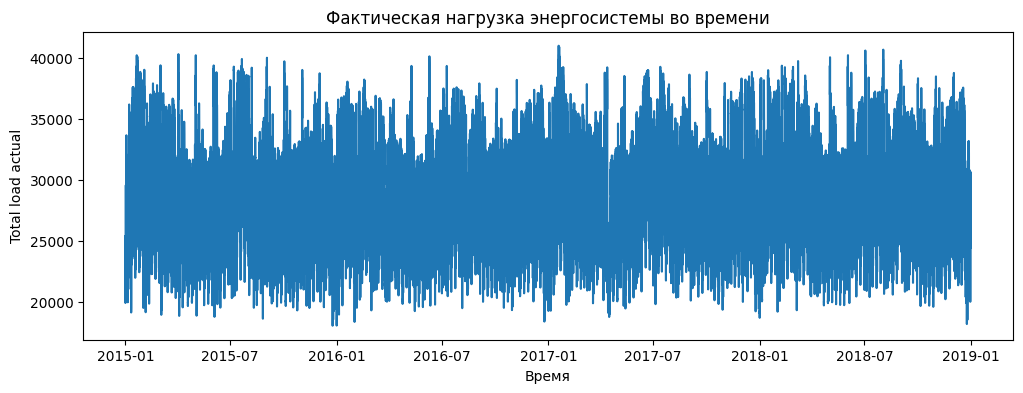

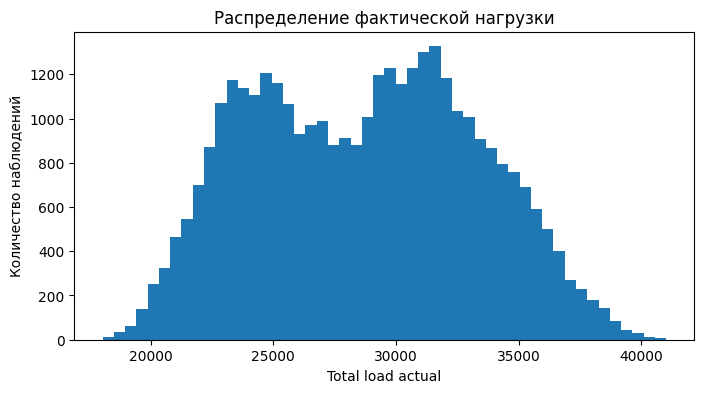

33% quantile: 25972.0
66% quantile: 31058.0

Class distribution:


load_class
0    11575
1    11568
2    11921
Name: count, dtype: int64

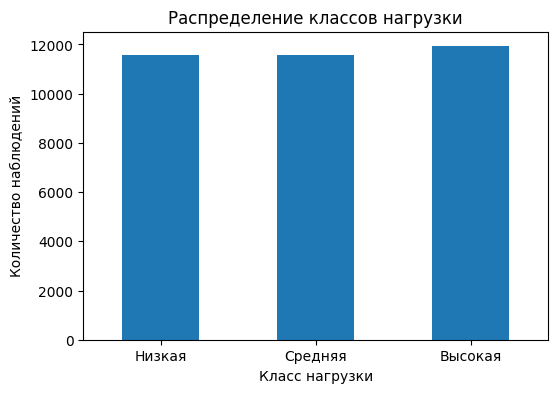

In [21]:
target_col = "total load actual"

print("Target column:", target_col)
print()

print("Basic statistics:")
display(df[target_col].describe())

plt.figure(figsize=(12, 4))
plt.plot(df["time"], df[target_col])
plt.title("Фактическая нагрузка энергосистемы во времени")
plt.xlabel("Время")
plt.ylabel("Total load actual")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df[target_col], bins=50)
plt.title("Распределение фактической нагрузки")
plt.xlabel("Total load actual")
plt.ylabel("Количество наблюдений")
plt.show()

q1 = df[target_col].quantile(0.33)
q2 = df[target_col].quantile(0.66)

print("33% quantile:", q1)
print("66% quantile:", q2)

def load_to_class(value):
    if value <= q1:
        return 0
    elif value <= q2:
        return 1
    else:
        return 2

df["load_class"] = df[target_col].apply(load_to_class)

print("\nClass distribution:")
display(df["load_class"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df["load_class"].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов нагрузки")
plt.xlabel("Класс нагрузки")
plt.ylabel("Количество наблюдений")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Низкая", "Средняя", "Высокая"],
    rotation=0
)
plt.show()

Анализ целевой переменной `total load actual` показал, что фактическая нагрузка энергосистемы изменяется в диапазоне от 18041 до 41015. Среднее значение составляет около 28698, медиана — около 28902. По графику временного ряда видно, что данные имеют выраженную периодичность и колебания нагрузки во времени, что делает их подходящими для применения рекуррентных нейронных сетей.

Для постановки задачи многоклассовой классификации нагрузка была разделена на три класса по квантилям: низкая нагрузка — значения до 25972, средняя нагрузка — значения от 25972 до 31058, высокая нагрузка — значения выше 31058. Такой способ разбиения позволил получить почти сбалансированные классы: 11575 наблюдений низкой нагрузки, 11568 наблюдений средней нагрузки и 11921 наблюдение высокой нагрузки. Это удобно для обучения модели, так как классы представлены примерно одинаково и не требуется дополнительная балансировка.

In [22]:
print("Columns in merged dataset:")
for i, col in enumerate(df.columns):
    print(i, col)

print("\nData types:")
display(df.dtypes)

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("\nNumeric columns:")
for col in numeric_cols:
    print(col)

print("\nNumber of numeric columns:", len(numeric_cols))

Columns in merged dataset:
0 time
1 generation biomass
2 generation fossil brown coal/lignite
3 generation fossil gas
4 generation fossil hard coal
5 generation fossil oil
6 generation hydro pumped storage consumption
7 generation hydro run-of-river and poundage
8 generation hydro water reservoir
9 generation nuclear
10 generation other
11 generation other renewable
12 generation solar
13 generation waste
14 generation wind onshore
15 forecast solar day ahead
16 forecast wind onshore day ahead
17 total load forecast
18 total load actual
19 price day ahead
20 price actual
21 temp
22 temp_min
23 temp_max
24 pressure
25 humidity
26 wind_speed
27 wind_deg
28 rain_1h
29 rain_3h
30 snow_3h
31 clouds_all
32 load_class

Data types:


time                                           datetime64[us, UTC]
generation biomass                                         float64
generation fossil brown coal/lignite                       float64
generation fossil gas                                      float64
generation fossil hard coal                                float64
generation fossil oil                                      float64
generation hydro pumped storage consumption                float64
generation hydro run-of-river and poundage                 float64
generation hydro water reservoir                           float64
generation nuclear                                         float64
generation other                                           float64
generation other renewable                                 float64
generation solar                                           float64
generation waste                                           float64
generation wind onshore                                    flo


Numeric columns:
generation biomass
generation fossil brown coal/lignite
generation fossil gas
generation fossil hard coal
generation fossil oil
generation hydro pumped storage consumption
generation hydro run-of-river and poundage
generation hydro water reservoir
generation nuclear
generation other
generation other renewable
generation solar
generation waste
generation wind onshore
forecast solar day ahead
forecast wind onshore day ahead
total load forecast
total load actual
price day ahead
price actual
temp
temp_min
temp_max
pressure
humidity
wind_speed
wind_deg
rain_1h
rain_3h
snow_3h
clouds_all
load_class

Number of numeric columns: 32


In [23]:
# Добавляем календарные признаки
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month

# Целевая колонка
target_col = "load_class"

# Все числовые признаки, кроме целевой переменной
feature_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols.remove(target_col)

print("Количество признаков:", len(feature_cols))
print("\nСписок признаков:")
for col in feature_cols:
    print("-", col)

print("\nЦелевая переменная:", target_col)

display(df[feature_cols + [target_col]].head())

Количество признаков: 34

Список признаков:
- generation biomass
- generation fossil brown coal/lignite
- generation fossil gas
- generation fossil hard coal
- generation fossil oil
- generation hydro pumped storage consumption
- generation hydro run-of-river and poundage
- generation hydro water reservoir
- generation nuclear
- generation other
- generation other renewable
- generation solar
- generation waste
- generation wind onshore
- forecast solar day ahead
- forecast wind onshore day ahead
- total load forecast
- total load actual
- price day ahead
- price actual
- temp
- temp_min
- temp_max
- pressure
- humidity
- wind_speed
- wind_deg
- rain_1h
- rain_3h
- snow_3h
- clouds_all
- hour
- day_of_week
- month

Целевая переменная: load_class


,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,...,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,hour,day_of_week,month,load_class
0,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,...,2.0,135.2,0.0,0.0,0.0,0.0,23,2,12,0
1,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,...,2.0,135.8,0.0,0.0,0.0,0.0,0,3,1,0
2,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,...,2.4,119.0,0.0,0.0,0.0,0.0,1,3,1,0
3,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,...,2.4,119.2,0.0,0.0,0.0,0.0,2,3,1,0
4,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,...,2.4,118.4,0.0,0.0,0.0,0.0,3,3,1,0


In [24]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# Делаем отдельную рабочую копию
df_model = df.copy()

# На всякий случай сортируем по времени
df_model = df_model.sort_values("time").reset_index(drop=True)

# Параметры задачи
window_size = 24          # 24 предыдущих часа
num_classes = 3           # низкая, средняя, высокая нагрузка

# Хронологическое разделение на train/test
train_size = int(len(df_model) * 0.8)

print("Всего строк:", len(df_model))
print("Граница train/test:", train_size)
print("Train time range:", df_model.loc[0, "time"], "->", df_model.loc[train_size - 1, "time"])
print("Test time range:", df_model.loc[train_size, "time"], "->", df_model.loc[len(df_model) - 1, "time"])
print()

# Нормализуем только входные признаки.
# Важно: scaler обучаем только на train-части, чтобы не было утечки данных из test.
scaler = StandardScaler()

scaler.fit(df_model.loc[:train_size - 1, feature_cols])

features_scaled = scaler.transform(df_model[feature_cols])
targets = df_model[target_col].values

print("features_scaled shape:", features_scaled.shape)
print("targets shape:", targets.shape)

Всего строк: 35064
Граница train/test: 28051
Train time range: 2014-12-31 23:00:00+00:00 -> 2018-03-14 17:00:00+00:00
Test time range: 2018-03-14 18:00:00+00:00 -> 2018-12-31 22:00:00+00:00

features_scaled shape: (35064, 34)
targets shape: (35064,)


In [25]:
def create_sequences(features, targets, window_size):
    X = []
    y = []
    target_indices = []

    for i in range(len(features) - window_size):
        # Берём 24 часа истории
        X.append(features[i:i + window_size])

        # Предсказываем класс следующего часа
        y.append(targets[i + window_size])

        # Запоминаем индекс целевой строки, чтобы потом корректно разделить train/test
        target_indices.append(i + window_size)

    return np.array(X), np.array(y), np.array(target_indices)


X, y, target_indices = create_sequences(
    features_scaled,
    targets,
    window_size
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("target_indices shape:", target_indices.shape)
print()

print("Пример:")
print("X[0] содержит строки df_model[0:24]")
print("y[0] соответствует строке df_model[24]")
print("target time:", df_model.loc[target_indices[0], "time"])
print("target class:", y[0])

X shape: (35040, 24, 34)
y shape: (35040,)
target_indices shape: (35040,)

Пример:
X[0] содержит строки df_model[0:24]
y[0] соответствует строке df_model[24]
target time: 2015-01-01 23:00:00+00:00
target class: 1


In [26]:
# Train — те последовательности, у которых целевой час находится в train-части
train_mask = target_indices < train_size

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[~train_mask]
y_test = y[~train_mask]

# One-hot encoding для categorical_crossentropy
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("y_train_cat shape:", y_train_cat.shape)
print()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("y_test_cat shape:", y_test_cat.shape)
print()

print("Train class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print()

print("Test class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

X_train shape: (28027, 24, 34)
y_train shape: (28027,)
y_train_cat shape: (28027, 3)

X_test shape: (7013, 24, 34)
y_test shape: (7013,)
y_test_cat shape: (7013, 3)

Train class distribution:
0    9344
1    9225
2    9458
Name: count, dtype: int64

Test class distribution:
0    2213
1    2337
2    2463
Name: count, dtype: int64


Получены входные данные формы `(28027, 24, 34)` для обучения и `(7013, 24, 34)` для тестирования. Это означает, что каждый обучающий пример содержит 24 последовательных часа истории, а на каждом часе находится 34 признака. Целевая переменная — класс нагрузки следующего часа. Распределение классов в train и test выборках примерно сбалансировано, поэтому на этом этапе дополнительная балансировка классов не требуется.

In [85]:
### ЭТО ФУНКЦИЯ УТИЛИТА, ЧТОБЫ ДЕЛАТЬ КРАСИВЫЙ ВЫВОД ГРАФИКОВ ПОСЛЕ ОБУЧЕНИЯ МОДЕЛЕЙ.

import matplotlib.pyplot as plt
import pandas as pd

def plot_model_results(results_df, model_name):
    df_plot = results_df.copy()

    # Для красивых подписей
    df_plot["label"] = (
        df_plot["optimizer"].astype(str)
        + " + "
        + df_plot["regularization"].astype(str)
    )

    # Сортируем по accuracy по убыванию
    df_plot = df_plot.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # ---------- Accuracy ----------
    axes[0].barh(df_plot["label"], df_plot["test_accuracy"])
    axes[0].set_title(f"Сравнение конфигураций {model_name} — Accuracy")
    axes[0].set_xlabel("Test accuracy")
    axes[0].set_ylabel("Конфигурация")
    axes[0].invert_yaxis()

    # Подписи значений
    for i, v in enumerate(df_plot["test_accuracy"]):
        axes[0].text(v + 0.001, i, f"{v:.4f}", va="center")

    # ---------- Loss ----------
    axes[1].barh(df_plot["label"], df_plot["test_loss"])
    axes[1].set_title(f"Сравнение конфигураций {model_name} — Loss")
    axes[1].set_xlabel("Test loss")
    axes[1].set_ylabel("Конфигурация")
    axes[1].invert_yaxis()

    # Подписи значений
    for i, v in enumerate(df_plot["test_loss"]):
        axes[1].text(v + 0.001, i, f"{v:.4f}", va="center")

    plt.tight_layout()
    plt.show()

### Simple RNN

Можно приступать к созданию простой рнн.

Для каждой архитектуры:
SimpleRNN
LSTM
GRU

проверить:
SGD
Momentum
RMSProp
Adam

и регуляризацию:
без регуляризации
L1
L2

### Памятка про окна.

На случай, если я забуду, почему используются окна:

вся задача сводится к тому, чтобы на основе предыдущих 24 часов выдать предсказание 25ого часа. в таком случае рнн вычисляет хидден стейт для всего 24 инпутов из 34 векторов и потом пара денс слоев. и софтмакс ну и да, небольшой такой момент, что мы вот эту операцию, вышеописанную делаем (28000 - 23) раз (для трейн).

X[i] = 24 часа истории
     = матрица 24 × 34

y[i] = класс нагрузки следующего часа


24 вектора по 34 признака
↓
SimpleRNN считает h₁, h₂, ..., h₂₄
↓
берём последнее состояние h₂₄
↓
Dense(32)
↓
Dense(3)
↓
Softmax
↓
вероятности трёх классов нагрузки 25-го часа


35064 исходных часа
window_size = 24

35064 - 24 = 35040 окон

In [73]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout

def get_optimizer(optimizer_name):
    if optimizer_name == "sgd":
        return SGD(learning_rate=0.01)
    
    if optimizer_name == "momentum":
        return SGD(learning_rate=0.01, momentum=0.9)
    
    if optimizer_name == "rmsprop":
        return RMSprop(learning_rate=0.001)
    
    if optimizer_name == "adam":
        return Adam(learning_rate=0.001)
    
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def get_regularizer(reg_type, strength=0.001):
    if reg_type is None:
        return None
    
    if reg_type == "l1":
        return regularizers.l1(strength)
    
    if reg_type == "l2":
        return regularizers.l2(strength)
    
    raise ValueError(f"Unknown regularization: {reg_type}")


def build_simple_rnn_model(
    input_shape,
    num_classes,
    optimizer_name="adam",
    reg_type=None,
    reg_strength=0.001,
    units=64,
    dense_units=32,
    dropout_rate=0.2
):
    reg = get_regularizer(reg_type, reg_strength)
    optimizer = get_optimizer(optimizer_name)

    model = Sequential([
        Input(shape=input_shape),

        SimpleRNN(
            units=units,
            activation="tanh",
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="simple_rnn_layer"
        ),

        Dropout(dropout_rate),

        Dense(
            units=dense_units,
            activation="relu",
            kernel_regularizer=reg,
            bias_regularizer=reg,
            name="dense_hidden"
        ),

        Dense(
            units=num_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [74]:
simple_rnn_experiments = []

optimizers_to_test = ["sgd", "momentum", "rmsprop", "adam"]
regularizations_to_test = [None, "l1", "l2"]

for optimizer_name in optimizers_to_test:
    for reg_type in regularizations_to_test:
        simple_rnn_experiments.append({
            "architecture": "SimpleRNN",
            "optimizer": optimizer_name,
            "regularization": reg_type
        })

simple_rnn_experiments

[{'architecture': 'SimpleRNN', 'optimizer': 'sgd', 'regularization': None},
 {'architecture': 'SimpleRNN', 'optimizer': 'sgd', 'regularization': 'l1'},
 {'architecture': 'SimpleRNN', 'optimizer': 'sgd', 'regularization': 'l2'},
 {'architecture': 'SimpleRNN',
  'optimizer': 'momentum',
  'regularization': None},
 {'architecture': 'SimpleRNN',
  'optimizer': 'momentum',
  'regularization': 'l1'},
 {'architecture': 'SimpleRNN',
  'optimizer': 'momentum',
  'regularization': 'l2'},
 {'architecture': 'SimpleRNN', 'optimizer': 'rmsprop', 'regularization': None},
 {'architecture': 'SimpleRNN', 'optimizer': 'rmsprop', 'regularization': 'l1'},
 {'architecture': 'SimpleRNN', 'optimizer': 'rmsprop', 'regularization': 'l2'},
 {'architecture': 'SimpleRNN', 'optimizer': 'adam', 'regularization': None},
 {'architecture': 'SimpleRNN', 'optimizer': 'adam', 'regularization': 'l1'},
 {'architecture': 'SimpleRNN', 'optimizer': 'adam', 'regularization': 'l2'}]

In [75]:
simple_rnn_results = []
simple_rnn_histories = {}
simple_rnn_models = {}

for exp in simple_rnn_experiments:
    optimizer_name = exp["optimizer"]
    reg_type = exp["regularization"]

    exp_name = f"SimpleRNN_{optimizer_name}_{reg_type if reg_type else 'no_reg'}"
    print("=" * 80)
    print("Training:", exp_name)
    print("=" * 80)

    np.random.seed(42)
    tf.random.set_seed(42)

    model = build_simple_rnn_model(
        input_shape=input_shape,
        num_classes=num_classes,
        optimizer_name=optimizer_name,
        reg_type=reg_type,
        reg_strength=0.001,
        units=64,
        dense_units=32,
        dropout_rate=0.2
    )

    # Новый EarlyStopping для каждой модели
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_cat,
        validation_split=0.2,
        epochs=15,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    simple_rnn_results.append({
        "architecture": "SimpleRNN",
        "optimizer": optimizer_name,
        "regularization": reg_type if reg_type else "none",
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "epochs_trained": len(history.history["loss"])
    })

    simple_rnn_histories[exp_name] = history
    simple_rnn_models[exp_name] = model

    print(f"{exp_name} test loss: {test_loss:.4f}")
    print(f"{exp_name} test accuracy: {test_accuracy:.4f}")

Training: SimpleRNN_sgd_no_reg
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6690 - loss: 0.7286 - val_accuracy: 0.7899 - val_loss: 0.5045
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7986 - loss: 0.4758 - val_accuracy: 0.8445 - val_loss: 0.3799
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8369 - loss: 0.3870 - val_accuracy: 0.8623 - val_loss: 0.3250
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8558 - loss: 0.3435 - val_accuracy: 0.8762 - val_loss: 0.2961
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8648 - loss: 0.3148 - val_accuracy: 0.8833 - val_loss: 0.2780
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.2922 - val_accuracy: 0.8903 - val_loss: 0.2632
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.2799 - val_accuracy: 0.8958 - val_loss: 0.2527
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8872 - 

In [76]:
simple_rnn_results_df = pd.DataFrame(simple_rnn_results)
simple_rnn_results_df = simple_rnn_results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

display(simple_rnn_results_df)

,architecture,optimizer,regularization,test_loss,test_accuracy,epochs_trained
7,SimpleRNN,rmsprop,l1,0.270678,0.933124,15
8,SimpleRNN,rmsprop,l2,0.223280,0.932269,15
11,SimpleRNN,adam,l2,0.228664,0.928704,15
5,SimpleRNN,momentum,l2,0.231807,0.924569,15
6,SimpleRNN,rmsprop,none,0.183380,0.923713,13
4,SimpleRNN,momentum,l1,0.274554,0.922145,15
10,SimpleRNN,adam,l1,0.270103,0.921146,15
3,SimpleRNN,momentum,none,0.202138,0.914302,7
9,SimpleRNN,adam,none,0.211912,0.913304,13
1,SimpleRNN,sgd,l1,0.799587,0.912163,15


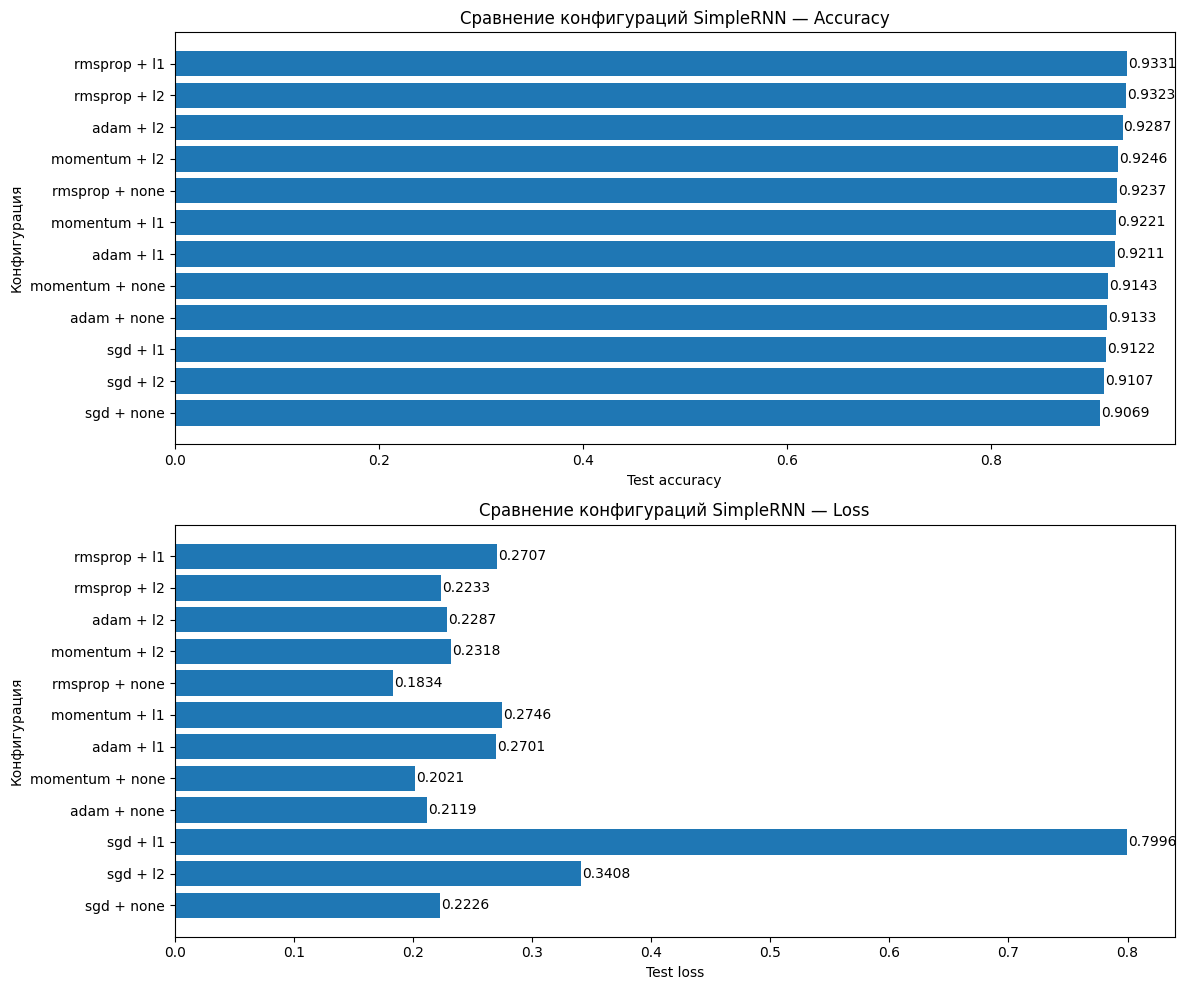

In [77]:
plot_model_results(simple_rnn_results_df, "SimpleRNN")

In [78]:
best_simple_rnn_row = simple_rnn_results_df.iloc[0]

best_simple_rnn_name = (
    f"SimpleRNN_{best_simple_rnn_row['optimizer']}_"
    f"{best_simple_rnn_row['regularization'] if best_simple_rnn_row['regularization'] != 'none' else 'no_reg'}"
)

print("Best SimpleRNN model:")
print(best_simple_rnn_name)

best_simple_rnn_model = simple_rnn_models[best_simple_rnn_name]
best_simple_rnn_history = simple_rnn_histories[best_simple_rnn_name]

Best SimpleRNN model:
SimpleRNN_rmsprop_l1


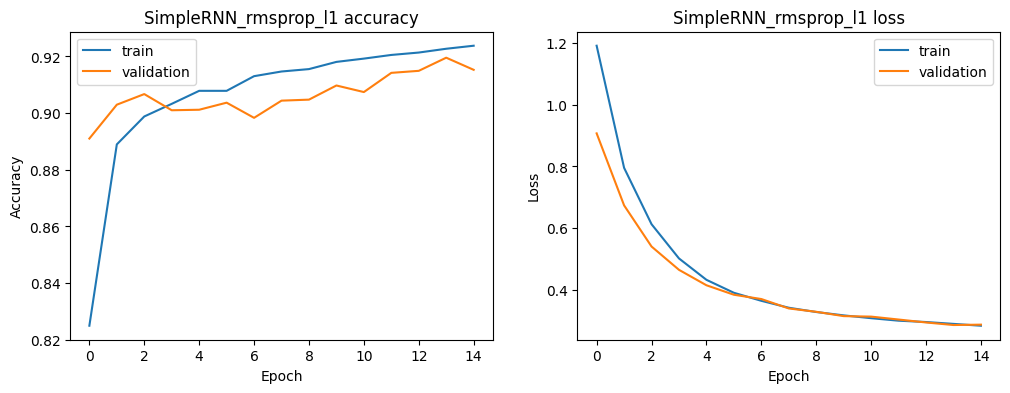

In [79]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_simple_rnn_history.history["accuracy"], label="train")
plt.plot(best_simple_rnn_history.history["val_accuracy"], label="validation")
plt.title(f"{best_simple_rnn_name} accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_simple_rnn_history.history["loss"], label="train")
plt.plot(best_simple_rnn_history.history["val_loss"], label="validation")
plt.title(f"{best_simple_rnn_name} loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### LSTM

In [80]:
from tensorflow.keras.layers import LSTM

def build_lstm_model(
    input_shape,
    num_classes,
    optimizer_name="adam",
    reg_type=None,
    reg_strength=0.001,
    units=64,
    dense_units=32,
    dropout_rate=0.2
):
    reg = get_regularizer(reg_type, reg_strength)
    optimizer = get_optimizer(optimizer_name)

    model = Sequential([
        Input(shape=input_shape),

        LSTM(
            units=units,
            activation="tanh",
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="lstm_layer"
        ),

        Dropout(dropout_rate),

        Dense(
            units=dense_units,
            activation="relu",
            kernel_regularizer=reg,
            bias_regularizer=reg,
            name="dense_hidden"
        ),

        Dense(
            units=num_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [81]:
lstm_experiments = []

optimizers_to_test = ["sgd", "momentum", "rmsprop", "adam"]
regularizations_to_test = [None, "l1", "l2"]

for optimizer_name in optimizers_to_test:
    for reg_type in regularizations_to_test:
        lstm_experiments.append({
            "architecture": "LSTM",
            "optimizer": optimizer_name,
            "regularization": reg_type
        })

lstm_experiments

[{'architecture': 'LSTM', 'optimizer': 'sgd', 'regularization': None},
 {'architecture': 'LSTM', 'optimizer': 'sgd', 'regularization': 'l1'},
 {'architecture': 'LSTM', 'optimizer': 'sgd', 'regularization': 'l2'},
 {'architecture': 'LSTM', 'optimizer': 'momentum', 'regularization': None},
 {'architecture': 'LSTM', 'optimizer': 'momentum', 'regularization': 'l1'},
 {'architecture': 'LSTM', 'optimizer': 'momentum', 'regularization': 'l2'},
 {'architecture': 'LSTM', 'optimizer': 'rmsprop', 'regularization': None},
 {'architecture': 'LSTM', 'optimizer': 'rmsprop', 'regularization': 'l1'},
 {'architecture': 'LSTM', 'optimizer': 'rmsprop', 'regularization': 'l2'},
 {'architecture': 'LSTM', 'optimizer': 'adam', 'regularization': None},
 {'architecture': 'LSTM', 'optimizer': 'adam', 'regularization': 'l1'},
 {'architecture': 'LSTM', 'optimizer': 'adam', 'regularization': 'l2'}]

In [82]:
lstm_results = []
lstm_histories = {}
lstm_models = {}

for exp in lstm_experiments:
    optimizer_name = exp["optimizer"]
    reg_type = exp["regularization"]

    exp_name = f"LSTM_{optimizer_name}_{reg_type if reg_type else 'no_reg'}"
    print("=" * 80)
    print("Training:", exp_name)
    print("=" * 80)

    np.random.seed(42)
    tf.random.set_seed(42)

    model = build_lstm_model(
        input_shape=input_shape,
        num_classes=num_classes,
        optimizer_name=optimizer_name,
        reg_type=reg_type,
        reg_strength=0.001,
        units=64,
        dense_units=32,
        dropout_rate=0.2
    )

    # Новый EarlyStopping для каждой модели
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_cat,
        validation_split=0.2,
        epochs=15,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    lstm_results.append({
        "architecture": "LSTM",
        "optimizer": optimizer_name,
        "regularization": reg_type if reg_type else "none",
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "epochs_trained": len(history.history["loss"])
    })

    lstm_histories[exp_name] = history
    lstm_models[exp_name] = model

    print(f"{exp_name} test loss: {test_loss:.4f}")
    print(f"{exp_name} test accuracy: {test_accuracy:.4f}")

Training: LSTM_sgd_no_reg
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5331 - loss: 0.9617 - val_accuracy: 0.6489 - val_loss: 0.8322
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6737 - loss: 0.7411 - val_accuracy: 0.7257 - val_loss: 0.6598
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7480 - loss: 0.5977 - val_accuracy: 0.7653 - val_loss: 0.5525
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7839 - loss: 0.5139 - val_accuracy: 0.7929 - val_loss: 0.4877
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8034 - loss: 0.4634 - val_accuracy: 0.8111 - val_loss: 0.4413
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8231 - loss: 0.4264 - val_accuracy: 0.8298 - val_loss: 0.4064
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8323 - loss: 0.3973 - val_accuracy: 0.8439 - val_loss: 0.3780
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8396 - loss:

In [83]:
lstm_results_df = pd.DataFrame(lstm_results)
lstm_results_df = lstm_results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

display(lstm_results_df)

,architecture,optimizer,regularization,test_loss,test_accuracy,epochs_trained
11,LSTM,adam,l2,0.238624,0.927991,15
7,LSTM,rmsprop,l1,0.296179,0.925995,15
8,LSTM,rmsprop,l2,0.251398,0.925852,15
10,LSTM,adam,l1,0.293493,0.921859,15
6,LSTM,rmsprop,none,0.194926,0.920861,9
5,LSTM,momentum,l2,0.264587,0.920291,15
3,LSTM,momentum,none,0.186990,0.919863,15
4,LSTM,momentum,l1,0.326702,0.919578,15
9,LSTM,adam,none,0.200135,0.918295,10
2,LSTM,sgd,l2,0.463155,0.892343,15


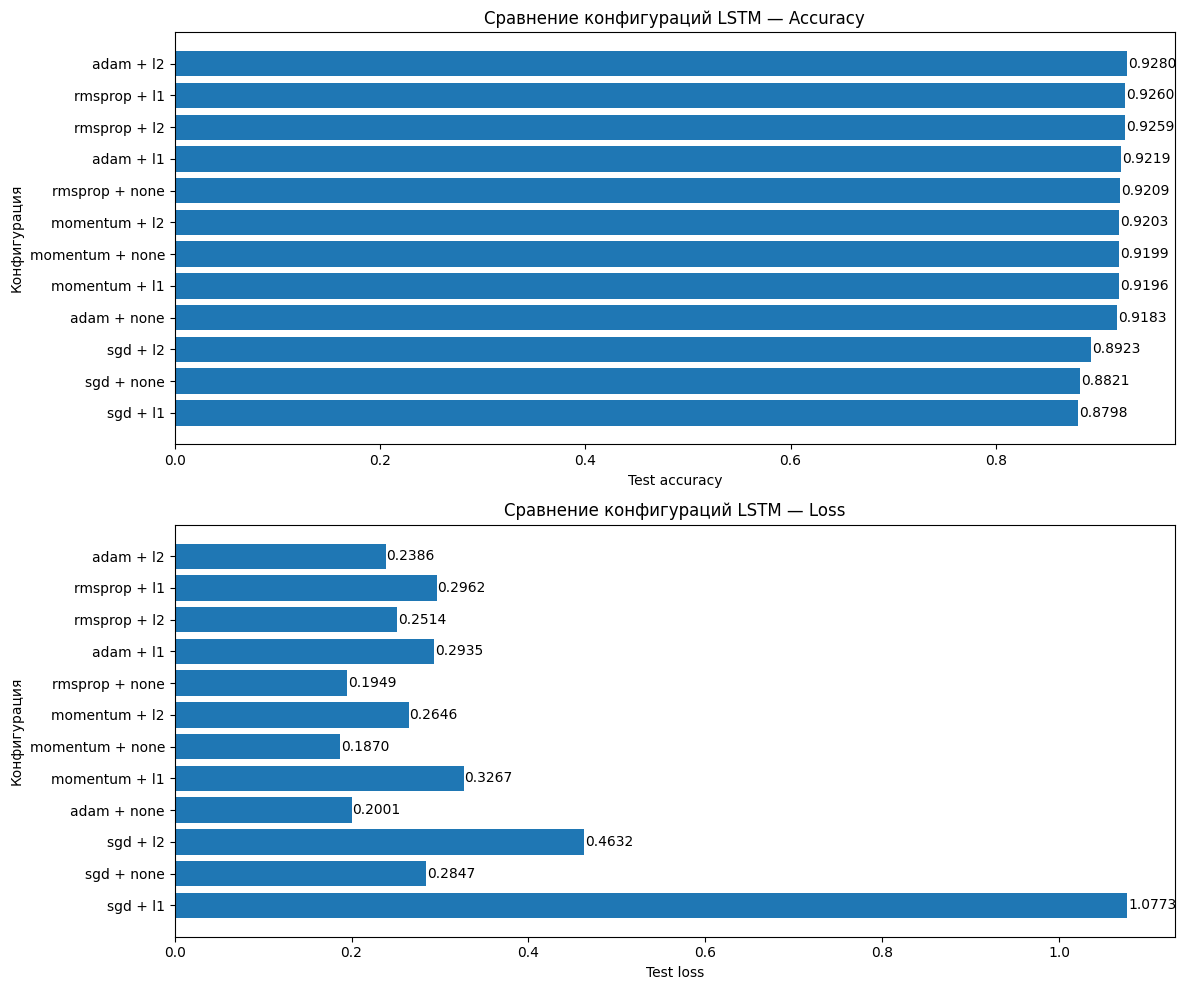

In [86]:
plot_model_results(lstm_results_df, "LSTM")

In [87]:
best_lstm_row = lstm_results_df.iloc[0]

best_lstm_name = (
    f"LSTM_{best_lstm_row['optimizer']}_"
    f"{best_lstm_row['regularization'] if best_lstm_row['regularization'] != 'none' else 'no_reg'}"
)

print("Best LSTM model:")
print(best_lstm_name)

best_lstm_model = lstm_models[best_lstm_name]
best_lstm_history = lstm_histories[best_lstm_name]

Best LSTM model:
LSTM_adam_l2


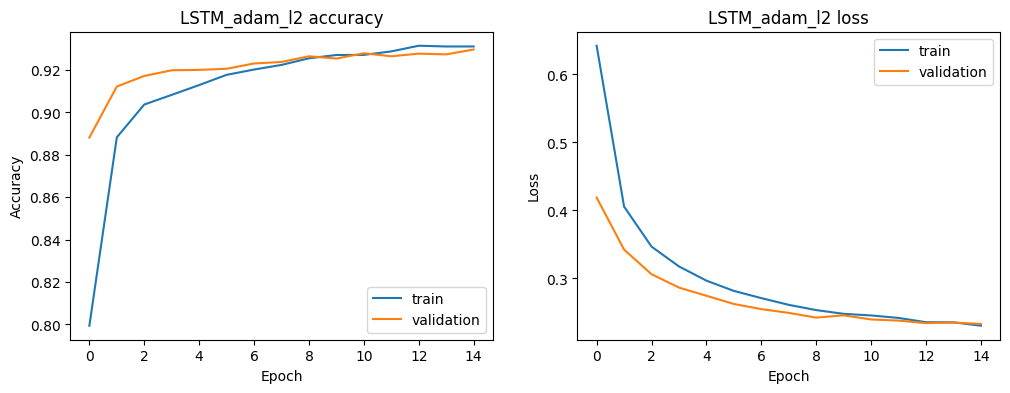

In [88]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_lstm_history.history["accuracy"], label="train")
plt.plot(best_lstm_history.history["val_accuracy"], label="validation")
plt.title(f"{best_lstm_name} accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_lstm_history.history["loss"], label="train")
plt.plot(best_lstm_history.history["val_loss"], label="validation")
plt.title(f"{best_lstm_name} loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### GRU

In [65]:
from tensorflow.keras.layers import GRU

def build_gru_model(
    input_shape,
    num_classes,
    optimizer_name="adam",
    reg_type=None,
    reg_strength=0.001,
    units=64,
    dense_units=32,
    dropout_rate=0.2
):
    reg = get_regularizer(reg_type, reg_strength)
    optimizer = get_optimizer(optimizer_name)

    model = Sequential([
        Input(shape=input_shape),

        GRU(
            units=units,
            activation="tanh",
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="gru_layer"
        ),

        Dropout(dropout_rate),

        Dense(
            units=dense_units,
            activation="relu",
            kernel_regularizer=reg,
            bias_regularizer=reg,
            name="dense_hidden"
        ),

        Dense(
            units=num_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [66]:
gru_experiments = []

optimizers_to_test = ["sgd", "momentum", "rmsprop", "adam"]
regularizations_to_test = [None, "l1", "l2"]

for optimizer_name in optimizers_to_test:
    for reg_type in regularizations_to_test:
        gru_experiments.append({
            "architecture": "GRU",
            "optimizer": optimizer_name,
            "regularization": reg_type
        })

gru_experiments

[{'architecture': 'GRU', 'optimizer': 'sgd', 'regularization': None},
 {'architecture': 'GRU', 'optimizer': 'sgd', 'regularization': 'l1'},
 {'architecture': 'GRU', 'optimizer': 'sgd', 'regularization': 'l2'},
 {'architecture': 'GRU', 'optimizer': 'momentum', 'regularization': None},
 {'architecture': 'GRU', 'optimizer': 'momentum', 'regularization': 'l1'},
 {'architecture': 'GRU', 'optimizer': 'momentum', 'regularization': 'l2'},
 {'architecture': 'GRU', 'optimizer': 'rmsprop', 'regularization': None},
 {'architecture': 'GRU', 'optimizer': 'rmsprop', 'regularization': 'l1'},
 {'architecture': 'GRU', 'optimizer': 'rmsprop', 'regularization': 'l2'},
 {'architecture': 'GRU', 'optimizer': 'adam', 'regularization': None},
 {'architecture': 'GRU', 'optimizer': 'adam', 'regularization': 'l1'},
 {'architecture': 'GRU', 'optimizer': 'adam', 'regularization': 'l2'}]

In [68]:
gru_results = []
gru_histories = {}
gru_models = {}

for exp in gru_experiments:
    optimizer_name = exp["optimizer"]
    reg_type = exp["regularization"]

    exp_name = f"GRU_{optimizer_name}_{reg_type if reg_type else 'no_reg'}"
    print("=" * 80)
    print("Training:", exp_name)
    print("=" * 80)

    np.random.seed(42)
    tf.random.set_seed(42)

    model = build_gru_model(
        input_shape=input_shape,
        num_classes=num_classes,
        optimizer_name=optimizer_name,
        reg_type=reg_type,
        reg_strength=0.001,
        units=64,
        dense_units=32,
        dropout_rate=0.2
    )

    # ВАЖНО: новый EarlyStopping для каждой модели
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_cat,
        validation_split=0.2,
        epochs=15,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    gru_results.append({
        "architecture": "GRU",
        "optimizer": optimizer_name,
        "regularization": reg_type if reg_type else "none",
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "epochs_trained": len(history.history["loss"])
    })

    gru_histories[exp_name] = history
    gru_models[exp_name] = model

    print(f"{exp_name} test loss: {test_loss:.4f}")
    print(f"{exp_name} test accuracy: {test_accuracy:.4f}")

Training: GRU_sgd_no_reg
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6269 - loss: 0.7976 - val_accuracy: 0.7281 - val_loss: 0.6166
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7577 - loss: 0.5647 - val_accuracy: 0.7940 - val_loss: 0.4848
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8072 - loss: 0.4645 - val_accuracy: 0.8264 - val_loss: 0.4080
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8331 - loss: 0.4020 - val_accuracy: 0.8562 - val_loss: 0.3553
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8507 - loss: 0.3598 - val_accuracy: 0.8700 - val_loss: 0.3182
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8601 - loss: 0.3307 - val_accuracy: 0.8776 - val_loss: 0.2934
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8685 - loss: 0.3120 - val_accuracy: 0.8833 - val_loss: 0.2763
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8722 - loss: 

In [69]:
gru_results_df = pd.DataFrame(gru_results)
gru_results_df = gru_results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

display(gru_results_df)

,architecture,optimizer,regularization,test_loss,test_accuracy,epochs_trained
9,GRU,adam,none,0.174049,0.928704,15
11,GRU,adam,l2,0.225122,0.928704,15
8,GRU,rmsprop,l2,0.233856,0.926850,15
6,GRU,rmsprop,none,0.179294,0.926850,13
5,GRU,momentum,l2,0.244828,0.923285,15
3,GRU,momentum,none,0.183812,0.921859,15
7,GRU,rmsprop,l1,0.292727,0.920576,15
4,GRU,momentum,l1,0.283450,0.920433,15
10,GRU,adam,l1,0.284751,0.919008,15
0,GRU,sgd,none,0.233360,0.903893,15


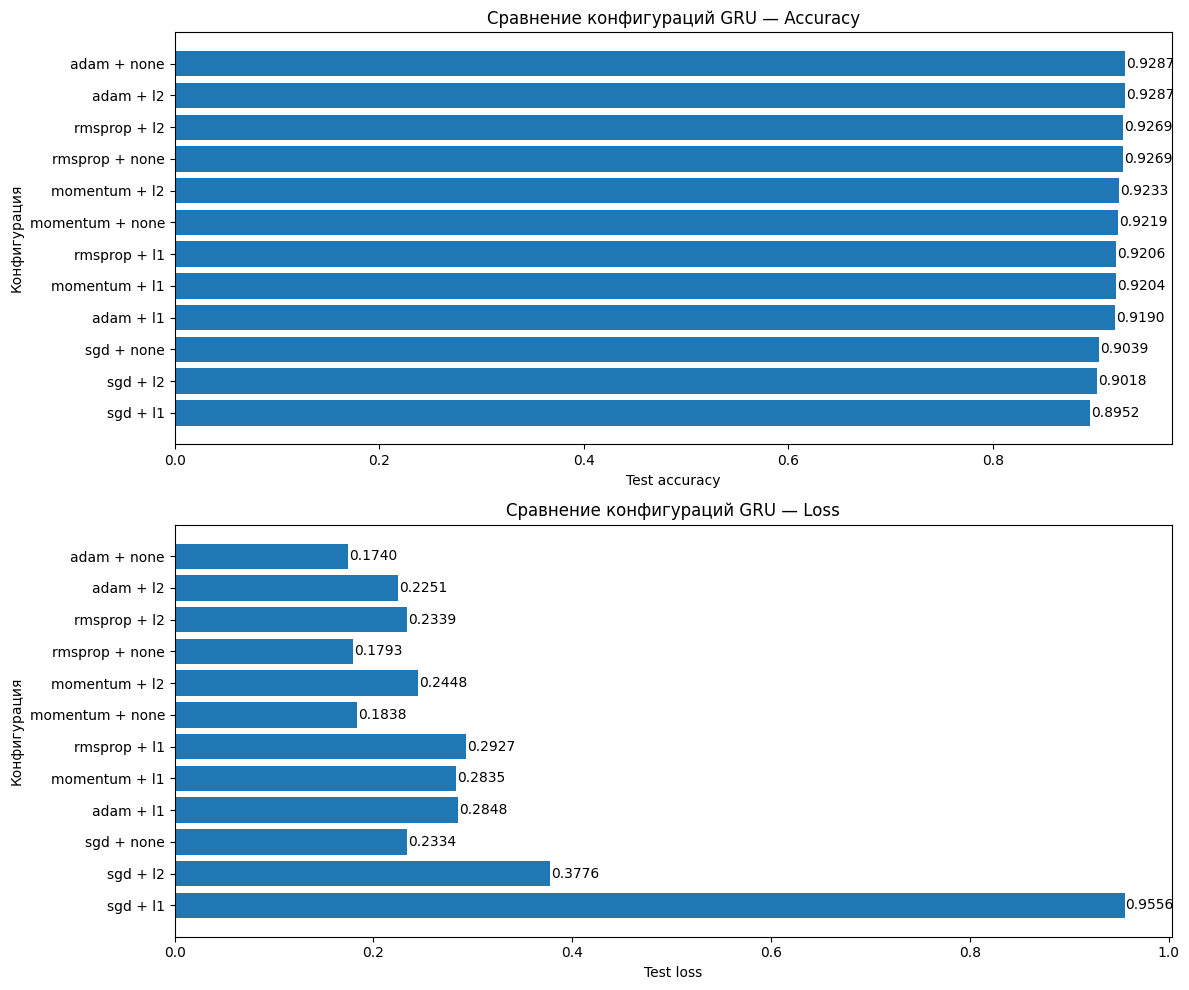

In [70]:
plot_model_results(gru_results_df, "GRU")

In [71]:
best_gru_row = gru_results_df.iloc[0]

best_gru_name = (
    f"GRU_{best_gru_row['optimizer']}_"
    f"{best_gru_row['regularization'] if best_gru_row['regularization'] != 'none' else 'no_reg'}"
)

print("Best GRU model:")
print(best_gru_name)

best_gru_model = gru_models[best_gru_name]
best_gru_history = gru_histories[best_gru_name]

Best GRU model:
GRU_adam_no_reg


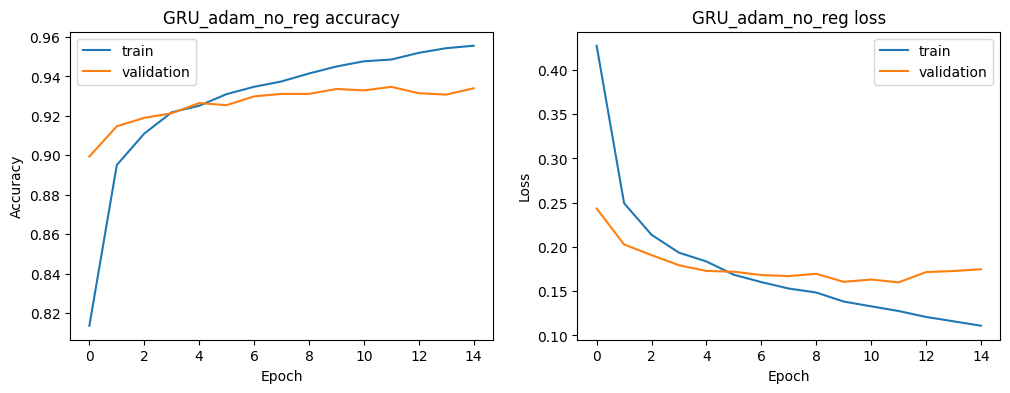

In [72]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_gru_history.history["accuracy"], label="train")
plt.plot(best_gru_history.history["val_accuracy"], label="validation")
plt.title(f"{best_gru_name} accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_gru_history.history["loss"], label="train")
plt.plot(best_gru_history.history["val_loss"], label="validation")
plt.title(f"{best_gru_name} loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Лучшие и худшие модели

SimpleRNN: лучшая и худшая конфигурации


,type,architecture,optimizer,regularization,test_accuracy,test_loss,epochs_trained
0,best,SimpleRNN,rmsprop,l1,0.933124,0.270678,15
1,worst,SimpleRNN,sgd,none,0.906887,0.222631,15


Best model name: SimpleRNN_rmsprop_l1
Worst model name: SimpleRNN_sgd_no_reg

Графики лучшей модели:


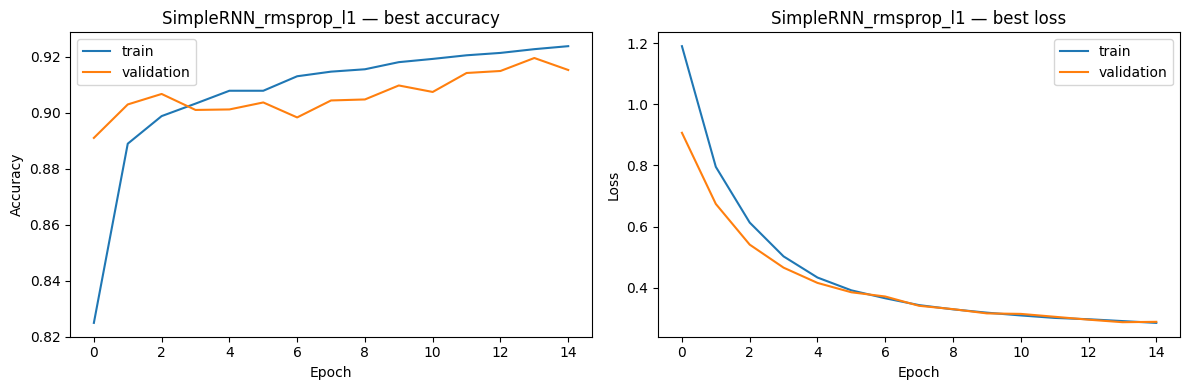


Графики худшей модели:


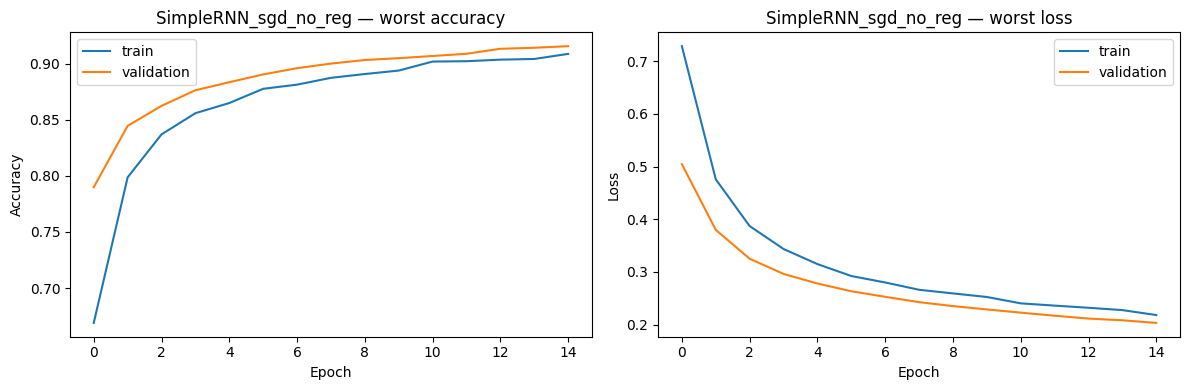

LSTM: лучшая и худшая конфигурации


,type,architecture,optimizer,regularization,test_accuracy,test_loss,epochs_trained
0,best,LSTM,adam,l2,0.927991,0.238624,15
1,worst,LSTM,sgd,l1,0.879795,1.077319,15


Best model name: LSTM_adam_l2
Worst model name: LSTM_sgd_l1

Графики лучшей модели:


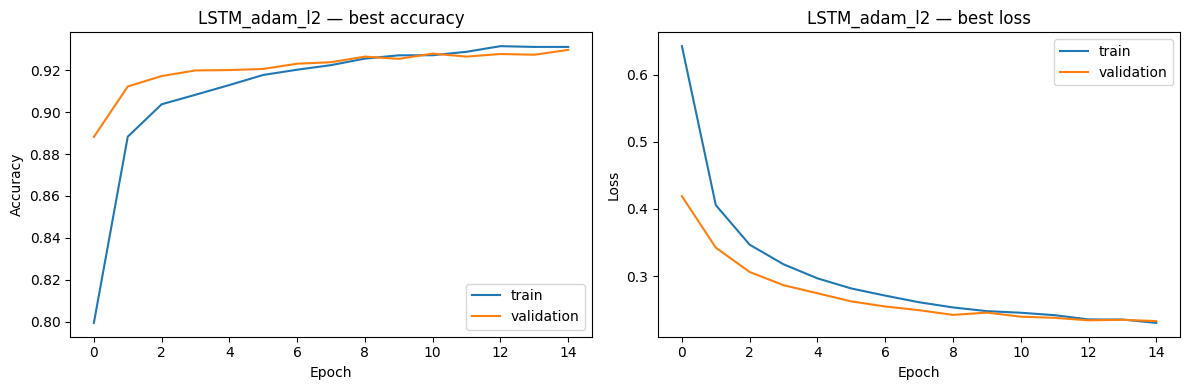


Графики худшей модели:


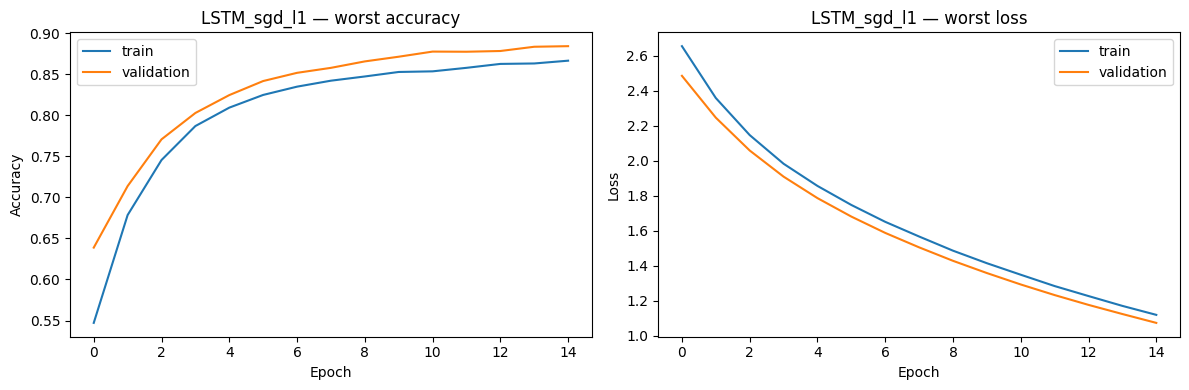

GRU: лучшая и худшая конфигурации


,type,architecture,optimizer,regularization,test_accuracy,test_loss,epochs_trained
0,best,GRU,adam,none,0.928704,0.174049,15
1,worst,GRU,sgd,l1,0.895195,0.955576,15


Best model name: GRU_adam_no_reg
Worst model name: GRU_sgd_l1

Графики лучшей модели:


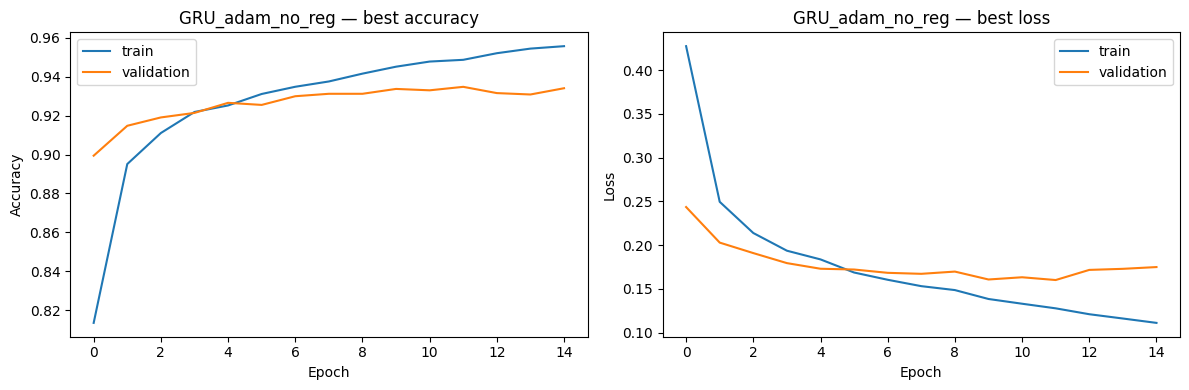


Графики худшей модели:


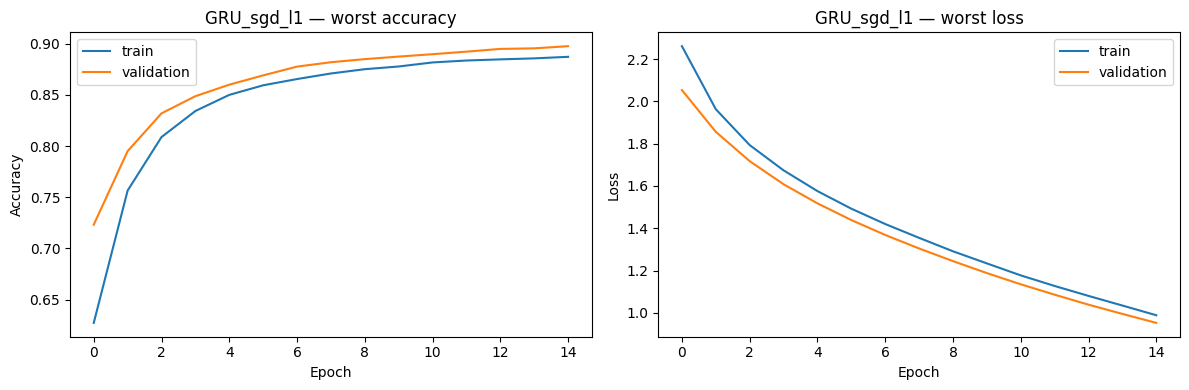

In [89]:
def get_experiment_name(architecture, optimizer, regularization):
    reg_part = regularization if regularization != "none" else "no_reg"
    return f"{architecture}_{optimizer}_{reg_part}"


def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title(f"{title} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="validation")
    plt.title(f"{title} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def show_best_and_worst(results_df, histories, architecture_name):
    df_sorted = results_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

    best_row = df_sorted.iloc[0]
    worst_row = df_sorted.iloc[-1]

    summary_df = pd.DataFrame([
        {
            "type": "best",
            "architecture": architecture_name,
            "optimizer": best_row["optimizer"],
            "regularization": best_row["regularization"],
            "test_accuracy": best_row["test_accuracy"],
            "test_loss": best_row["test_loss"],
            "epochs_trained": best_row["epochs_trained"],
        },
        {
            "type": "worst",
            "architecture": architecture_name,
            "optimizer": worst_row["optimizer"],
            "regularization": worst_row["regularization"],
            "test_accuracy": worst_row["test_accuracy"],
            "test_loss": worst_row["test_loss"],
            "epochs_trained": worst_row["epochs_trained"],
        }
    ])

    print("=" * 80)
    print(f"{architecture_name}: лучшая и худшая конфигурации")
    print("=" * 80)
    display(summary_df)

    best_name = get_experiment_name(
        architecture_name,
        best_row["optimizer"],
        best_row["regularization"]
    )

    worst_name = get_experiment_name(
        architecture_name,
        worst_row["optimizer"],
        worst_row["regularization"]
    )

    print("Best model name:", best_name)
    print("Worst model name:", worst_name)

    print("\nГрафики лучшей модели:")
    plot_history(histories[best_name], f"{best_name} — best")

    print("\nГрафики худшей модели:")
    plot_history(histories[worst_name], f"{worst_name} — worst")

    return summary_df


simple_rnn_best_worst = show_best_and_worst(
    simple_rnn_results_df,
    simple_rnn_histories,
    "SimpleRNN"
)

lstm_best_worst = show_best_and_worst(
    lstm_results_df,
    lstm_histories,
    "LSTM"
)

gru_best_worst = show_best_and_worst(
    gru_results_df,
    gru_histories,
    "GRU"
)